# RAG 任务一：与 `task1_main.py` 完全一致的九步流程

本 Notebook 直接调用项目中的真实模块，主流程严格对应 `task1_main.py`。  
它不重复实现加载器、分块器、Embedding、检索器或 LLM 客户端，便于学习项目代码如何组合成完整 RAG。

主流程完成后提供“可选附录：质量分析与可视化”。附录只复用主流程变量，不改变 RAG 执行逻辑。

## 环境准备

这里导入 `task1_main.py` 使用的真实模块和同一个 `build_rag_prompt()`。  
另外导入 NumPy、Matplotlib 和 JSON，仅供主流程结果展示及附录分析使用。

In [ ]:
import json
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from src.rag import DocumentLoader, Chunker, EmbeddingModel, Retriever
from src.llm import LLMClient
from config import CONFIG
from task1_main import build_rag_prompt

matplotlib.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

print(f"LLM 模型: {CONFIG['llm']['model']}")
print(f"Embedding 模型: {CONFIG['embedding']['model_name']}")

真实项目模块导入成功
LLM 模型: deepseek-v4-pro
Embedding 模型: paraphrase-multilingual-MiniLM-L12-v2


## 步骤 1：加载三篇知识库文档

- **为什么需要**：RAG 首先需要可检索的外部知识。
- **真实模块**：`src.rag.DocumentLoader`。
- **输入**：`CONFIG["knowledge_base"]["accident"]` 中配置的 Markdown 文件路径。
- **输出**：`docs`，每篇文档包含正文和来源元数据。
- **RAG 职责**：把磁盘上的知识文件转换为后续分块器可处理的统一文档对象。

In [2]:
docs = DocumentLoader.load(CONFIG["knowledge_base"]["accident"])

print(f"已加载 {len(docs)} 篇文档")
for doc in docs:
    print(f"- {doc.metadata.get('filename', '未知来源')}：{len(doc.content)} 字符")

已加载 3 篇文档
- doc1_定义与成因.md：909 字符
- doc2_应急处置与救援.md：1311 字符
- doc3_法律责任与赔偿.md：2245 字符


## 步骤 2：按配置切分文档

- **为什么需要**：整篇文档过长且主题混杂，不适合直接进行细粒度检索。
- **真实模块**：`src.rag.Chunker`。
- **输入**：`docs`、配置中的 `chunk_size` 和 `overlap`。
- **输出**：`chunks`，包含正文及文档标题、父标题、当前标题等层级元数据。
- **RAG 职责**：建立可独立召回、又保留上下文层级的最小知识单元。

In [3]:
chunker = Chunker(
    chunk_size=CONFIG["rag"]["chunk_size"],
    overlap=CONFIG["rag"]["chunk_overlap"],
)
chunks = chunker.split(docs)

print(f"已生成 {len(chunks)} 个 Chunks")
for chunk in chunks[:3]:
    print(
        f"- {chunk.metadata.get('document_title')} / "
        f"{chunk.metadata.get('parent_header')} / "
        f"{chunk.metadata.get('current_header')}：{len(chunk.text)} 字符"
    )

已生成 19 个 Chunks
- # 高速公路追尾事故的定义与成因 / ## 一、什么是高速公路追尾事故？ / ## 一、什么是高速公路追尾事故？：152 字符
- # 高速公路追尾事故的定义与成因 / ## 二、追尾事故的主要成因分析 / ## 二、追尾事故的主要成因分析：345 字符
- # 高速公路追尾事故的定义与成因 / ## 三、法律责任认定 / ## 三、法律责任认定：167 字符


## 步骤 3：初始化 Embedding 模型

- **为什么需要**：文本必须转换为数值向量，才能计算问题与知识块的语义相似度。
- **真实模块**：`src.rag.EmbeddingModel`。
- **输入**：配置中的多语言 Sentence Transformers 模型名。
- **输出**：`embedding_model`。
- **RAG 职责**：为问题和 Chunk 提供处于同一向量空间的语义表示。

In [4]:
embedding_model = EmbeddingModel(CONFIG["embedding"]["model_name"])
print(f"Embedding 模型初始化完成：{CONFIG['embedding']['model_name']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding 模型初始化完成：paraphrase-multilingual-MiniLM-L12-v2


## 步骤 4：构建检索索引

- **为什么需要**：预先编码所有 Chunk，查询时才能快速比较相似度。
- **真实模块**：`src.rag.Retriever`。
- **输入**：`embedding_model` 和 `chunks`。
- **输出**：已建立索引的 `retriever`。
- **RAG 职责**：保存 Chunk 向量，并提供候选召回与标题重排序能力。

In [5]:
retriever = Retriever(embedding_model)
retriever.index(chunks)

print(f"检索索引构建完成，共索引 {len(retriever.chunks)} 个 Chunks")
print(f"向量矩阵形状：{retriever.chunk_embeddings.shape}")

检索索引构建完成，共索引 19 个 Chunks
向量矩阵形状：(19, 384)


## 步骤 5：初始化 DeepSeek LLM 客户端

- **为什么需要**：检索器负责找到证据，LLM 负责基于证据组织自然语言回答。
- **真实模块**：`src.llm.LLMClient`。
- **输入**：`CONFIG["llm"]` 中的 DeepSeek API 配置，API Key 从 `.env` 读取。
- **输出**：`llm_client`。
- **RAG 职责**：执行最终的受上下文约束的回答生成。

In [6]:
llm_client = LLMClient(
    api_key=CONFIG["llm"]["api_key"],
    base_url=CONFIG["llm"]["base_url"],
    model=CONFIG["llm"]["model"],
)
print(f"DeepSeek LLM 客户端初始化完成：{CONFIG['llm']['model']}")

DeepSeek LLM 客户端初始化完成：deepseek-v4-pro


## 步骤 6：设置用户问题

- **为什么需要**：问题是检索和生成阶段共同围绕的查询目标。
- **真实模块**：本步骤与 `task1_main.py` 使用同一个主问题。
- **输入**：字符串“什么是高速追尾事故？”。
- **输出**：`question`。
- **RAG 职责**：定义本次检索和回答生成的需求。

In [7]:
question = "什么是高速追尾事故？"
print(f"用户问题：{question}")

用户问题：什么是高速追尾事故？


## 步骤 7：候选 Top-5 召回并重排序为最终 Top-3

- **为什么需要**：先扩大候选范围，再融合语义相似度和标题匹配度，可以减少相关章节漏召回。
- **真实模块**：`Retriever.query()`。
- **输入**：`question`、`candidate_k=5`、`top_k=3`。
- **输出**：`results`，每项包含 Chunk、向量分数、标题分数和最终综合分数。
- **RAG 职责**：从知识库选出最适合传给 LLM 的三段证据。

In [8]:
results = retriever.query(
    question,
    candidate_k=CONFIG["rag"]["candidate_k"],
    top_k=CONFIG["rag"]["top_k"],
)

print(f"检索到 {len(results)} 个最终结果：")
for rank, result in enumerate(results, 1):
    chunk = result.chunk
    print(
        f"{rank}. {chunk.metadata.get('document_title')} / "
        f"{chunk.metadata.get('parent_header')} / "
        f"{chunk.metadata.get('current_header')}"
    )
    print(
        f"   最终分数={result.final_score:.4f} | "
        f"向量分数={result.vector_score:.4f} | "
        f"标题分数={result.title_score:.4f}"
    )

检索到 3 个最终结果：
1. # 高速公路追尾事故的定义与成因 / ## 一、什么是高速公路追尾事故？ / ## 一、什么是高速公路追尾事故？
   最终分数=0.6552 | 向量分数=0.6164 | 标题分数=0.8750
2. # 高速公路追尾事故的定义与成因 / ## 二、追尾事故的主要成因分析 / ## 二、追尾事故的主要成因分析
   最终分数=0.5897 | 向量分数=0.6056 | 标题分数=0.5000
3. # 高速公路追尾事故的定义与成因 / ## 四、预防措施 / ## 四、预防措施
   最终分数=0.5633 | 向量分数=0.5745 | 标题分数=0.5000


## 步骤 8：构造同一个 RAG Prompt 并调用 LLM

- **为什么需要**：必须明确要求模型只依据检索证据回答，降低脱离知识库生成内容的风险。
- **真实模块**：`task1_main.build_rag_prompt()` 与 `LLMClient.chat()`。
- **输入**：用户问题和步骤 7 的 Top-3 检索结果。
- **输出**：`prompt`、`messages` 和 `answer`。
- **RAG 职责**：把问题和证据组合为生成模型可理解的指令，并请求 DeepSeek 生成答案。

In [9]:
prompt = build_rag_prompt(question, results)
messages = [{"role": "user", "content": prompt}]

print("发送给 DeepSeek 的 Prompt：")
print(prompt)

answer = llm_client.chat(messages)
print("\nDeepSeek 调用完成")

发送给 DeepSeek 的 Prompt：
请根据以下文档内容回答问题。

    文档内容：
    【文档片段1】
## 一、什么是高速公路追尾事故？

高速公路追尾事故是指在同一条车道上，后车车头与前车车尾发生碰撞的交通事故。这是高速公路上常见的事故类型之一。

追尾事故通常发生在以下场景：
- 前车突然减速或停车
- 后车跟车距离过近
- 驾驶员注意力分散
- 恶劣天气导致能见度降低
- 路面湿滑导致制动距离延长

【文档片段2】
## 二、追尾事故的主要成因分析

### 1. 跟车距离不足

根据《道路交通安全法实施条例》第八十条规定，机动车在高速公路上行驶，车速超过100公里/小时时，与同车道前车距离应保持在100米以上；车速低于100公里/小时时，与同车道前车距离可适当缩短，但最小距离不得少于50米。然而，许多驾驶员忽视这一规定，导致紧急情况下无法及时刹车。

### 2. 注意力分散

驾驶员使用手机、调节导航、与乘客交谈等行为会导致注意力分散，延长反应时间，增加追尾风险。

### 3. 超速行驶

车速越高，反应距离和制动距离显著增加。超速会大幅缩短驾驶员应对突发情况的时间窗口。

### 4. 恶劣天气影响

雨、雪、雾等恶劣天气会降低路面摩擦系数，延长制动距离，同时降低能见度，增加追尾风险。

【文档片段3】
## 四、预防措施

1. **保持安全车距**：可参考"三秒法则"；在高速公路上还应遵守法定车距要求，车速超过100公里/小时时保持100米以上，车速低于100公里/小时时最小不得少于50米
2. **集中注意力**：避免驾驶时使用手机等分散注意力的行为
3. **控制车速**：根据路况和天气调整车速
4. **定期检查**：确保刹车系统、轮胎状况良好
5. **使用辅助系统**：合理利用ACC自适应巡航、AEB自动紧急制动等辅助系统

    问题：什么是高速追尾事故？

    请仅根据文档内容回答，如果文档中没有相关信息，请说明。回答要准确、完整。

DeepSeek 调用完成


## 步骤 9：输出最终回答

- **为什么需要**：向用户呈现基于知识库证据生成的最终结果。
- **真实模块**：直接输出步骤 8 返回的 `answer`。
- **输入**：`answer`。
- **输出**：最终自然语言答案。
- **RAG 职责**：完成“检索增强生成”的最终交付。

In [10]:
print("最终回答：")
print(answer)

最终回答：
根据文档内容，高速公路追尾事故是指在同一条车道上，后车车头与前车车尾发生碰撞的交通事故。


# 可选附录：质量分析与可视化

以下内容**不是 `task1_main.py` 的必需流程**，仅用于理解和分析效果。  
附录直接复用主流程已经产生的 `docs`、`chunks`、`embedding_model`、`retriever` 和 `results`，不重新实现核心类，也不重复执行九步主流程。

## 附录 A：导出当前 Chunk

将真实 `Chunker` 生成的结果导出一次，便于检查层级元数据和正文内容。

In [11]:
os.makedirs("output/chunks", exist_ok=True)

chunk_records = [
    {"index": index, "content": chunk.text, "metadata": chunk.metadata}
    for index, chunk in enumerate(chunks)
]
with open("output/chunks/chunks.json", "w", encoding="utf-8") as file:
    json.dump(chunk_records, file, ensure_ascii=False, indent=2)

with open("output/chunks/chunks.txt", "w", encoding="utf-8") as file:
    for record in chunk_records:
        file.write(f"===== Chunk {record['index']} =====\n")
        file.write(json.dumps(record["metadata"], ensure_ascii=False) + "\n")
        file.write(record["content"] + "\n\n")

print("已导出 output/chunks/chunks.json 和 output/chunks/chunks.txt")

已导出 output/chunks/chunks.json 和 output/chunks/chunks.txt


## 附录 B：Chunk 长度与文档分布

左图用于检查分块长度是否合理，右图用于检查三篇知识文档在索引中的 Chunk 数量分布。

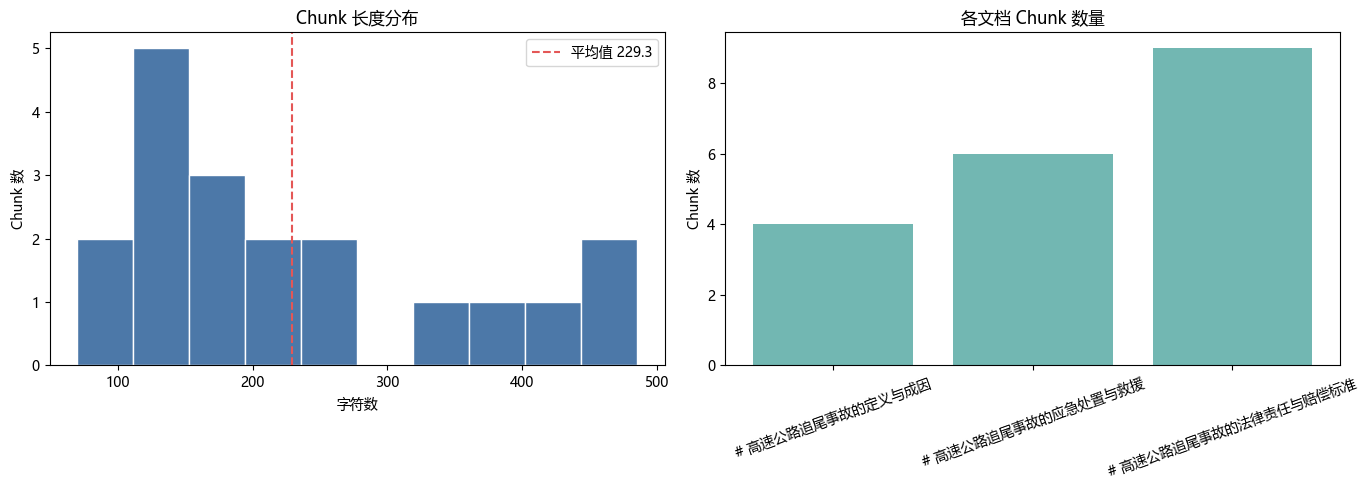

In [12]:
lengths = [len(chunk.text) for chunk in chunks]
source_names = [chunk.metadata.get("document_title", "未知文档") for chunk in chunks]
unique_sources, source_counts = np.unique(source_names, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(lengths, bins=min(10, len(lengths)), color="#4C78A8", edgecolor="white")
axes[0].axvline(np.mean(lengths), color="#E45756", linestyle="--", label=f"平均值 {np.mean(lengths):.1f}")
axes[0].set_title("Chunk 长度分布")
axes[0].set_xlabel("字符数")
axes[0].set_ylabel("Chunk 数")
axes[0].legend()

axes[1].bar(unique_sources, source_counts, color="#72B7B2")
axes[1].set_title("各文档 Chunk 数量")
axes[1].set_ylabel("Chunk 数")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("output/chunk_visualization.png", dpi=180, bbox_inches="tight")
plt.show()

## 附录 C：问题 × Chunk 相似度热图与单个向量示例

热图每一行是一个测试问题，每一列是一个 Chunk。颜色越深，表示该问题与对应 Chunk 的向量相似度越高。  
旁边的单个向量图只用于证明文本已被编码为数值向量。

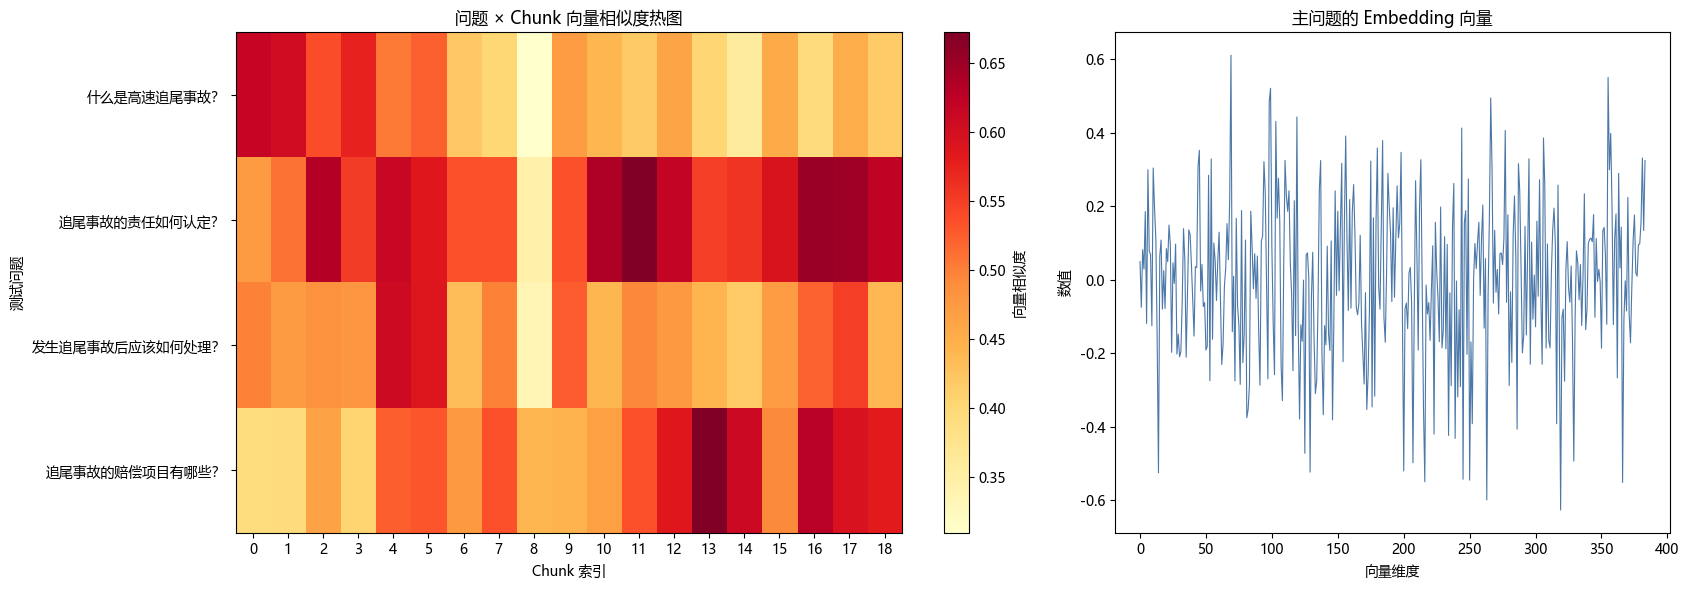

In [13]:
evaluation_cases = [
    ("什么是高速追尾事故？", "定义"),
    ("追尾事故的责任如何认定？", "责任认定"),
    ("发生追尾事故后应该如何处理？", "紧急处理"),
    ("追尾事故的赔偿项目有哪些？", "赔偿项目与标准"),
]

evaluation_questions = [case[0] for case in evaluation_cases]
question_embeddings = embedding_model.encode(evaluation_questions)
similarity_matrix = np.vstack([
    retriever.get_all_similarities(test_question)
    for test_question in evaluation_questions
])

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [3, 2]})
heatmap = axes[0].imshow(similarity_matrix, aspect="auto", cmap="YlOrRd")
axes[0].set_title("问题 × Chunk 向量相似度热图")
axes[0].set_xlabel("Chunk 索引")
axes[0].set_ylabel("测试问题")
axes[0].set_yticks(range(len(evaluation_questions)))
axes[0].set_yticklabels(evaluation_questions)
axes[0].set_xticks(range(len(chunks)))
fig.colorbar(heatmap, ax=axes[0], label="向量相似度")

vector = question_embeddings[0]
axes[1].plot(vector, color="#4C78A8", linewidth=0.8)
axes[1].set_title("主问题的 Embedding 向量")
axes[1].set_xlabel("向量维度")
axes[1].set_ylabel("数值")

plt.tight_layout()
plt.savefig("output/embedding_visualization.png", dpi=180, bbox_inches="tight")
plt.show()

## 附录 D：主问题重排序分数

该图展示最终 Top-3 的向量分数、标题匹配分数和按 85%/15% 融合后的最终分数。

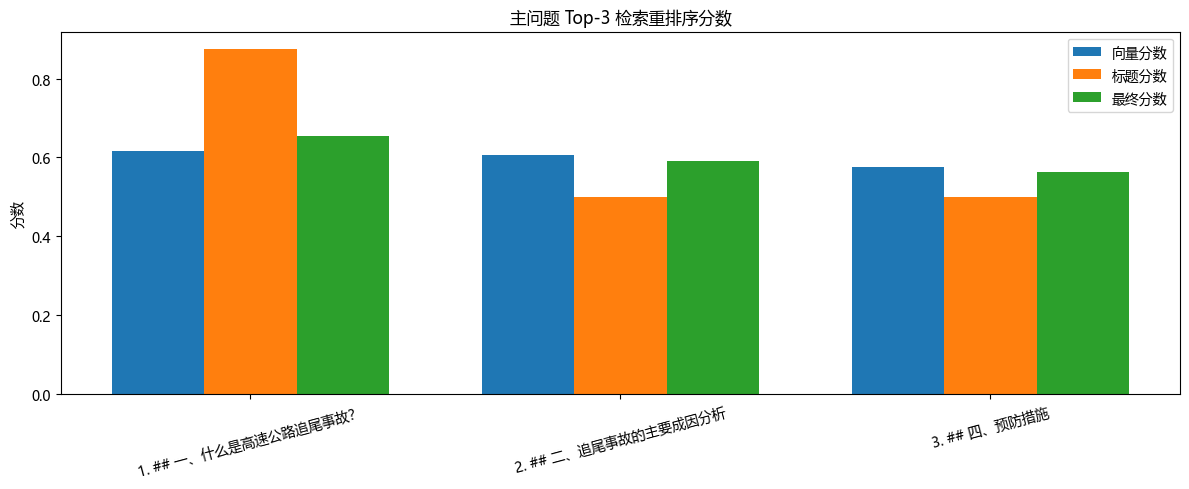

In [14]:
labels = [
    f"{rank}. {result.chunk.metadata.get('current_header', '无标题')}"
    for rank, result in enumerate(results, 1)
]
vector_scores = [result.vector_score for result in results]
title_scores = [result.title_score for result in results]
final_scores = [result.final_score for result in results]

x = np.arange(len(results))
width = 0.25
plt.figure(figsize=(12, 5))
plt.bar(x - width, vector_scores, width, label="向量分数")
plt.bar(x, title_scores, width, label="标题分数")
plt.bar(x + width, final_scores, width, label="最终分数")
plt.xticks(x, labels, rotation=15)
plt.ylabel("分数")
plt.title("主问题 Top-3 检索重排序分数")
plt.legend()
plt.tight_layout()
plt.savefig("output/retrieval_visualization.png", dpi=180, bbox_inches="tight")
plt.show()

## 附录 E：四问题检索质量评估

- `Hit@3`：期望章节是否出现在最终 Top-3。
- `Recall@5`：期望章节是否出现在初始候选 Top-5。
- `MRR`：期望章节排名倒数的平均值，越接近 1 表示排名越靠前。

评估仍调用真实 `Retriever.query()`，不会调用 LLM，因此只衡量检索质量。

In [15]:
def matches_expected(result, expected_header):
    metadata = result.chunk.metadata
    searchable_headers = " ".join(
        str(metadata.get(key, ""))
        for key in ("document_title", "parent_header", "current_header")
    )
    return expected_header in searchable_headers


evaluation_rows = []
for test_question, expected_header in evaluation_cases:
    candidate_results = retriever.query(test_question, candidate_k=5, top_k=5)
    first_rank = next(
        (rank for rank, result in enumerate(candidate_results, 1)
         if matches_expected(result, expected_header)),
        None,
    )
    evaluation_rows.append(
        {
            "问题": test_question,
            "期望章节": expected_header,
            "Hit@3": first_rank is not None and first_rank <= 3,
            "Recall@5": first_rank is not None and first_rank <= 5,
            "倒数排名": 0.0 if first_rank is None else 1.0 / first_rank,
            "首次命中排名": first_rank,
        }
    )

for row in evaluation_rows:
    print(
        f"{row['问题']} | 期望={row['期望章节']} | "
        f"首次命中排名={row['首次命中排名']} | "
        f"Hit@3={row['Hit@3']} | Recall@5={row['Recall@5']}"
    )

hit_at_3 = np.mean([row["Hit@3"] for row in evaluation_rows])
recall_at_5 = np.mean([row["Recall@5"] for row in evaluation_rows])
mrr = np.mean([row["倒数排名"] for row in evaluation_rows])

print(f"\nHit@3 = {hit_at_3:.0%}")
print(f"Recall@5 = {recall_at_5:.0%}")
print(f"MRR = {mrr:.3f}")

什么是高速追尾事故？ | 期望=定义 | 首次命中排名=1 | Hit@3=True | Recall@5=True
追尾事故的责任如何认定？ | 期望=责任认定 | 首次命中排名=2 | Hit@3=True | Recall@5=True
发生追尾事故后应该如何处理？ | 期望=紧急处理 | 首次命中排名=1 | Hit@3=True | Recall@5=True
追尾事故的赔偿项目有哪些？ | 期望=赔偿项目与标准 | 首次命中排名=1 | Hit@3=True | Recall@5=True

Hit@3 = 100%
Recall@5 = 100%
MRR = 0.875
